In [137]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

deg2rad = np.pi / 180.0
rad2deg = 180.0 / np.pi

R = 6.96e8
dt = 0.001
alpha = 6.048e13
dphi = 0.5*deg2rad
dtheta1_d = 0.5*3
dtheta2_d = 1
dtheta3_d = 0.5
tot_time = 365*5
N_steps = int(tot_time / dt)
save = 100
N_save = int(N_steps / save)+1
N_phi = int(2*np.pi/ dphi)
v_mer_max = 1.296e6
omega_max_deg = 13.38
omega_max = omega_max_deg*deg2rad

theta_1n = np.arange(5, 30, dtheta1_d)
theta_2n = np.arange(30, 60, dtheta2_d)
theta_3 = np.arange(60, 120, dtheta3_d)
theta_2s = np.arange(120, 150, dtheta2_d)
theta_1s = np.arange(150, 180 - 5, dtheta1_d)

print("theta_1n:", theta_1n.shape)
print("theta_2n:", theta_2n.shape)  
print("theta_3:", theta_3.shape)
print("theta_2s:", theta_2s.shape)
print("theta_1s:", theta_1s.shape)

N_theta = (len(theta_1n) + len(theta_2n) + len(theta_3) + len(theta_2s) + len(theta_1s))
theta_deg = np.concatenate((theta_1n, theta_2n, theta_3, theta_2s, theta_1s))

theta = theta_deg * deg2rad
dtheta1 = dtheta1_d * deg2rad
dtheta2 = dtheta2_d * deg2rad
dtheta3 = dtheta3_d * deg2rad

delta_x = R*np.min(np.sin(theta))*dphi
delta_y = R*dtheta3

stab_par = min((min(delta_x**2,delta_y**2))/(4*alpha), delta_y/v_mer_max, dphi/omega_max)
print(f"stab_par: {stab_par}")
assert dt <= stab_par, "Stability condition violated!!!!!!!!!!!"

phi = np.arange(0, 2 * np.pi, dphi)
Phi, Theta = np.meshgrid(phi, theta)
Phi_grid, Theta_grid = np.meshgrid(phi, theta, indexing='ij')

Phi_deg = Phi * rad2deg
Theta_deg = Theta * rad2deg

df = pd.read_csv("sunspots_input.dat", sep=r"\s+", header=None)
df.to_csv("input.csv", index=False)
df.columns = ['phase', 'latitude', 'tilt','radius in Mm','longitude', 'flux in Mx']
df['flux in Mx'] = df['flux in Mx'] * 1e16
df['radius in Mm'] = df['radius in Mm'] * 1e1 
bmr = df.to_numpy()
bmr_added = np.zeros(len(bmr), dtype=bool)

theta_1n: (17,)
theta_2n: (30,)
theta_3: (120,)
theta_2s: (30,)
theta_1s: (17,)
stab_par: 0.0011583330978429725


In [138]:
print(df)

      phase  latitude      tilt  radius in Mm  longitude    flux in Mx
0         1       -22 -4.312603     74.942842         63  1.081406e+21
1         2        23  4.409528     64.524913        155  8.231345e+20
2         2       -26 -4.688294     40.260272        308  3.204567e+20
3         3        34  5.361269     44.602547        183  4.803827e+20
4         3       -21 -4.213449     15.085714        192  5.495406e+19
...     ...       ...       ...           ...        ...           ...
2992    152         2  1.300299     30.118318         50  2.336306e+20
2993    152        -4 -1.838900     38.672602          6  3.851901e+20
2994    152         5  2.055953     30.429389        259  2.384816e+20
2995    152        -3 -1.592534     16.764424        354  7.238450e+19
2996    152         9  2.758350     19.871604        205  1.017031e+20

[2997 rows x 6 columns]


In [139]:
(4*deg2rad)**2

0.004873878716587337

In [140]:
np.min(np.sin(theta))

np.float64(0.08715574274765817)

In [141]:
T = np.zeros_like(Theta)

In [142]:
N_phi, N_theta

(720, 214)

In [143]:
Phi.shape, Theta.shape, T.shape

((214, 720), (214, 720), (214, 720))

In [144]:
dtheta_rad = np.zeros(N_theta)
dtheta_rad[:len(theta_1n)] = dtheta1
dtheta_rad[len(theta_1n):len(theta_1n) + len(theta_2n)] = dtheta2
dtheta_rad[len(theta_1n) + len(theta_2n):len(theta_1n) + len(theta_2n) + len(theta_3)] = dtheta3
dtheta_rad[len(theta_1n) + len(theta_2n) + len(theta_3):len(theta_1n) + len(theta_2n) + len(theta_3) + len(theta_2s)] = dtheta2
dtheta_rad[len(theta_1n) + len(theta_2n) + len(theta_3) + len(theta_2s):] = dtheta1

In [145]:
print(T.shape)
T = T.T
print(T.shape)

(214, 720)
(720, 214)


In [146]:
omega = omega_max - (2.3 * (np.cos(theta))**2 - 1.62* (np.cos(theta))**4) * deg2rad

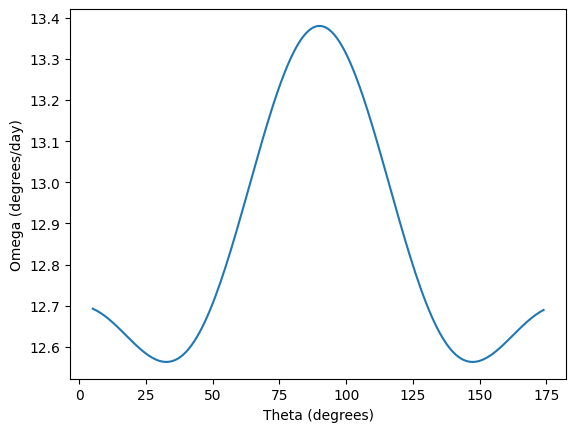

In [147]:
plt.plot(theta_deg, omega * rad2deg)
plt.xlabel("Theta (degrees)")
plt.ylabel(f"Omega (degrees/day)")
plt.show()

In [148]:
col = theta*rad2deg-90
v_mer = np.where(np.abs(col)<=75, v_mer_max * np.sin(np.pi * col / 75), 0)

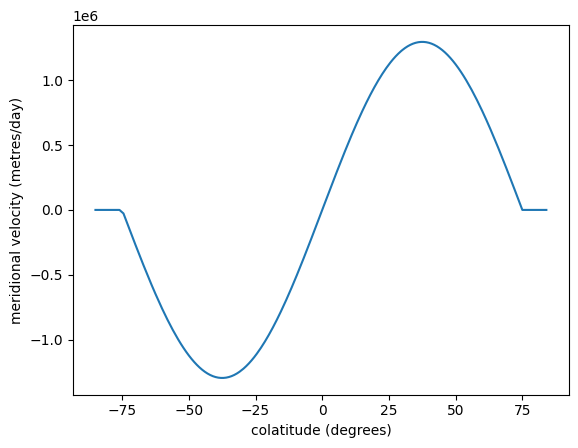

In [149]:
plt.plot(col, v_mer)
plt.xlabel("colatitude (degrees)")
plt.ylabel("meridional velocity (metres/day)")
plt.show()

In [150]:
cot = 1/np.tan(theta)
sin2 = (np.sin(theta))**2
senin = 1/(np.sin(theta))
cos = np.cos(theta).astype(np.float32)
sin = np.sin(theta).astype(np.float32)
all_values = np.zeros((N_save, N_phi, N_theta),dtype=np.float32)
T = T.astype(np.float32)
all_values[0, :, :] = T
T_new = np.zeros_like(T).astype(np.float32)
T_new.shape

(720, 214)

In [151]:
accum_bottom = np.zeros(N_phi)
accum_top = np.zeros(N_phi)
save_idx = 0
all_values[save_idx, :, :]  = T
all_values[save_idx, :, 0]  = accum_bottom
all_values[save_idx, :, -1] = accum_top
save_idx += 1

In [152]:
C_phi_local = np.abs(omega) * dt / dphi
C_theta_local = np.abs(v_mer) * dt / (R * dtheta_rad)

print(f"Max C_phi = {np.max(C_phi_local):.4f}, Max C_theta = {np.max(C_theta_local):.4f}")

if np.max(C_phi_local) > 1.0 or np.max(C_theta_local) > 1.0:
    print("Warning: Local advection CFL > 1 — explicit scheme may become unstable.")


Max C_phi = 0.0268, Max C_theta = 0.0002


In [153]:
current_month = 0
next_bmr_index = 0

In [ ]:
for n in range(1, N_steps + 1):
    t_days = n * dt
    month = int(t_days/30)

    if month > current_month:
        print(f"{month} month(s) start")
        current_month = month

    idx = next_bmr_index
    while idx < len(bmr) and not bmr_added[idx] and month >= bmr[idx, 0]:

        phase = bmr[idx, 0]
        lat_deg = bmr[idx, 1]
        tilt_deg = bmr[idx, 2]
        radius_Mm = bmr[idx, 3]
        lon_deg = bmr[idx, 4]
        flux = bmr[idx, 5]

        if month < phase:
            continue

        lat = lat_deg * deg2rad
        lon = lon_deg * deg2rad
        tilt = tilt_deg * deg2rad
        theta_c = np.pi/2.0 - lat

        R_cm = R * 100.0
        radius_cm = radius_Mm * 1e8

        ang_rad = radius_cm / R_cm # half angle of spot from centr
        sep_factor = 3.0
        d = sep_factor * ang_rad  # angular separation between spots

        dx = (d / 2.0) * np.cos(tilt)
        dy = (d / 2.0) * np.sin(tilt)
        dphi_off = dx / np.cos(lat)    # small angle correction for longitude
        dtheta_off = -dy
        theta_pos = theta_c + dtheta_off
        theta_neg = theta_c - dtheta_off
        phi_pos = lon + dphi_off
        phi_neg = lon - dphi_off

        flux_pos = flux
        flux_neg = -flux # assumed that the input flux is given for each spot(leading or following) 
                                #currently multiplied radius by root(2) *10 and flux by 1e8 bcoz flux assumed in webers and radius assumed error

        cap_area = 2.0 * np.pi * (R_cm**2) * (1.0 - np.cos(ang_rad)) #cm^2

        B0_pos = flux_pos / cap_area
        B0_neg = flux_neg / cap_area

        B0_pos_T = B0_pos * 1e-4
        B0_neg_T = B0_neg * 1e-4

        print("Inserting BMR idx=", idx, "phase=", phase, "month=", month)
        print(f" lat={lat_deg:.2f} deg, lon={lon_deg:.2f} deg, tilt={tilt_deg:.2f} deg")
        print(f" radius(Mm)={radius_Mm:.3f}, radius_cm={radius_cm:.3e}, ang_rad(deg)={(ang_rad*rad2deg):.4f}")
        print(f" flux(Mx)={flux:.3e}, cap_area(cm2)={cap_area:.3e}")
        print(f" B0_pos(T)={B0_pos_T:.3e}, B0_neg(T)={B0_neg_T:.3e}")

        cos_gamma_pos = (np.sin(Theta_grid) * np.sin(theta_pos) * np.cos(Phi_grid - phi_pos)
                         + np.cos(Theta_grid) * np.cos(theta_pos))
        cos_gamma_pos = np.clip(cos_gamma_pos, -1.0, 1.0)
        mask_pos = (cos_gamma_pos >= np.cos(ang_rad))
        T[mask_pos] += B0_pos_T

        cos_gamma_neg = (np.sin(Theta_grid) * np.sin(theta_neg) * np.cos(Phi_grid - phi_neg) + np.cos(Theta_grid) * np.cos(theta_neg))
        cos_gamma_neg = np.clip(cos_gamma_neg, -1.0, 1.0)
        mask_neg = (cos_gamma_neg >= np.cos(ang_rad))
        T[mask_neg] += B0_neg_T

        npos = np.count_nonzero(mask_pos)
        nneg = np.count_nonzero(mask_neg)
        print(f" mask cells pos={npos}, neg={nneg}")
        
        bmr_added[idx] = True
        next_bmr_index += 1
        idx = next_bmr_index
    i_sl = slice(1, -1)
    j_sl = slice(1, -1)

    Tc   = T[i_sl, j_sl]                 
    T_ip = T[2:,  j_sl]                  
    T_im = T[:-2, j_sl]                 
    T_jp = T[i_sl, 2:]                   
    T_jm = T[i_sl, :-2]                  

    dth     = dtheta_rad[1:-1]         
    inv_dth = 1.0 / dth
    inv_dth2= inv_dth**2
    sin_i   = sin[1:-1]
    sin2_i  = sin2[1:-1]
    cos_i   = cos[1:-1]
    cot_i   = cot[1:-1]
    sin_c    = sin[1:-1]                   
    sin_ph   = sin[2:]                      
    sin_mh   = sin[:-2]                    
    omg_c    = omega[1:-1]                  
    v_ph     = 0.5*(v_mer[1:-1] + v_mer[2:])  
    v_mh     = 0.5*(v_mer[:-2]  + v_mer[1:-1]) 

    eps = 1e-1
    sin_i_safe  = np.maximum(sin_i,  eps)
    sin2_i_safe = np.maximum(sin2_i, eps**2)
    cot_i_safe = np.maximum(cot_i, eps)
    d2T_dtheta = (T_jp - 2.0 * Tc + T_jm) * inv_dth2
    cot_term   = cot_i_safe * ((Tc - T_jm) * inv_dth)
    d2T_dphi   = (T_ip - 2.0 * Tc + T_im) / (dphi**2)

    diffusion = (alpha / (R**2)) * dt * (d2T_dtheta + cot_term + (d2T_dphi / sin2_i_safe))   #diffusion term

    div_phi = omg_c * (Tc - T_im) / dphi   #-omega(theta) * del(B)/del(phi)

    vph_pos = v_ph >= 0
    vmh_pos = v_mh >= 0

    T_up_ph = np.where(vph_pos, Tc, T_jp)  
    Fth_ph  = v_ph * T_up_ph                

    T_up_mh = np.where(vmh_pos, T_jm, Tc) 
    Fth_mh  = v_mh * T_up_mh

    div_theta = (sin_ph * Fth_ph - sin_mh * Fth_mh) / dth  
    div_theta = div_theta / (R * np.maximum(sin_c, 1e-8))   

    advection = -div_phi - div_theta

    T_new[i_sl, j_sl] = Tc + diffusion + dt * advection

    if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
        print(f"Numerical instability at step {n}")
        print(f"Max value in T_new: {np.nanmax(T_new)}, Min value: {np.nanmin(T_new)}")
        bad_indices = np.argwhere(~np.isfinite(T_new))
        print(f"Non-finite entries at indices (i,j): {bad_indices[:10]}")
        break

    T_new[0,   1:-1] = T_new[-2, 1:-1]
    T_new[-1,  1:-1] = T_new[1,  1:-1]

    accum_bottom += T_new[:, 1]
    accum_top    += T_new[:, -2]
    T_new[1:-1, 0]  = T_new[1:-1, 1]
    T_new[1:-1, -1] = T_new[1:-1, -2]
    T = T_new.copy()
    if (n % 100) == 0:
        all_values[save_idx, :, :]  = T
        all_values[save_idx, :, 0]  = accum_bottom
        all_values[save_idx, :, -1] = accum_top
        save_idx += 1

In [ ]:
all_values = np.transpose(all_values, (0, 2, 1))

In [ ]:
from matplotlib.animation import FuncAnimation
fig, ax = plt.subplots()
#vmin = np.min(all_values)
#vmax = np.max(all_values)
cax = ax.imshow(all_values[0], extent=[0, 360, 90, -90], aspect='equal', origin='lower', cmap='seismic', vmin=-1e-3, vmax=1e-3)
fig.colorbar(cax, label='Magnetic field strength (Tesla)')
ax.set_title('2D Magnetic Field')
ax.set_ylabel('θ (degrees)')
ax.set_xlabel('φ (degrees)')
ax.set_xticks(np.arange(0, 361, 30))
ax.set_yticks(np.arange(90, -91, -15))
ax.grid(True)
ax.invert_yaxis()

def animate(frame):
    data = all_values[frame]
    ax.set_title(f'Magnetic field of a sunspot at t = {frame*dt*100:.2f} days')
    cax.set_data(data)
    return [cax]

ani = FuncAnimation(fig, animate, frames=range(0, all_values.shape[0], 100), interval=1000, blit=True, repeat=False)

plt.close(fig)
from IPython.display import HTML
HTML(ani.to_jshtml())

In [ ]:
from matplotlib.animation import PillowWriter
writer = PillowWriter(fps=2)
ani.save('induction_equation_1_year.gif', writer=writer)